In [4]:
import torch
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from torch import nn
import numpy as np
import matplotlib.pyplot as plt

In [33]:
X, y = make_moons(n_samples=1000, random_state=42, noise = 0.1)
X[:5], y[:5]

(array([[-0.05146968,  0.44419863],
        [ 1.03201691, -0.41974116],
        [ 0.86789186, -0.25482711],
        [ 0.288851  , -0.44866862],
        [-0.83343911,  0.53505665]]),
 array([1, 1, 1, 1, 0]))

In [34]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
len(X_train), len(X_test)

(800, 200)

In [35]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layers = nn.Sequential(
            nn.Linear(in_features=2, out_features=12),
            nn.ReLU(),
            nn.Linear(in_features=12, out_features=12),
            nn.ReLU(),
            nn.Linear(in_features=12, out_features=1)
        )
    def forward(self, x):
        return self.linear_layers(x)

model_0 = ClassificationModel()
model_0

ClassificationModel(
  (linear_layers): Sequential(
    (0): Linear(in_features=2, out_features=12, bias=True)
    (1): ReLU()
    (2): Linear(in_features=12, out_features=12, bias=True)
    (3): ReLU()
    (4): Linear(in_features=12, out_features=1, bias=True)
  )
)

In [36]:
from torchmetrics.classification import BinaryAccuracy
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)
torch_accuracy = BinaryAccuracy()

In [37]:
torch.manual_seed(42)
epochs = 10000
for epoch in range(epochs):
    model_0.train()
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits, y_train)
    acc = torch_accuracy(y_logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_logits = model_0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        test_loss = loss_fn(test_logits, y_test)
        test_acc = torch_accuracy(test_logits, y_test)
    if epoch % 500 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Acc: {acc*100:.2f}% | Test Loss: {test_loss:.5f}, Test Acc: {test_acc*100:.2f}%")

Epoch: 0 | Loss: 0.68166, Acc: 50.00% | Test Loss: 0.68509, Test Acc: 50.00%
Epoch: 500 | Loss: 0.56480, Acc: 75.12% | Test Loss: 0.58192, Test Acc: 71.00%
Epoch: 1000 | Loss: 0.45557, Acc: 79.62% | Test Loss: 0.47704, Test Acc: 76.00%
Epoch: 1500 | Loss: 0.38516, Acc: 83.25% | Test Loss: 0.40162, Test Acc: 82.00%
Epoch: 2000 | Loss: 0.33338, Acc: 85.75% | Test Loss: 0.34282, Test Acc: 84.50%
Epoch: 2500 | Loss: 0.29852, Acc: 87.38% | Test Loss: 0.30102, Test Acc: 86.00%
Epoch: 3000 | Loss: 0.27753, Acc: 88.25% | Test Loss: 0.27602, Test Acc: 88.00%
Epoch: 3500 | Loss: 0.26352, Acc: 88.25% | Test Loss: 0.25982, Test Acc: 88.50%
Epoch: 4000 | Loss: 0.25228, Acc: 88.25% | Test Loss: 0.24719, Test Acc: 89.00%
Epoch: 4500 | Loss: 0.24161, Acc: 88.25% | Test Loss: 0.23503, Test Acc: 89.50%
Epoch: 5000 | Loss: 0.22951, Acc: 89.12% | Test Loss: 0.22171, Test Acc: 90.00%
Epoch: 5500 | Loss: 0.21262, Acc: 90.12% | Test Loss: 0.20512, Test Acc: 92.00%
Epoch: 6000 | Loss: 0.18522, Acc: 92.50% | T

In [38]:
with torch.inference_mode():
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

test_pred[:10], y_test[:10]

(tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

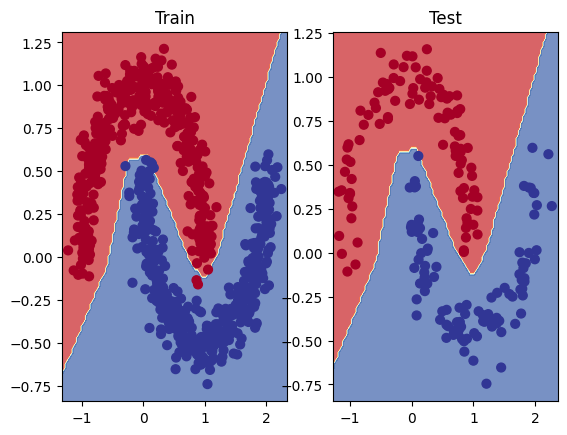

In [39]:
from helper_functions import plot_decision_boundary
plt.Figure(figsize=(12,6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)